#Worksheet-6

###**Data Understanding and Visualization:**
Download the Provided Data and Complete the following task.

Load and visualize images from a dataset stored in directories, where each subdirectory represents a class. You are expected to write a code:

• Get the list of class directories from the train folder.

• Select one image randomly from each class.

• Display the images in a grid format with two rows using matplotlib.

In [63]:
import os
print(os.listdir('/content'))

['.config', 'FruitinAmazon', 'vgg16_model.keras', 'FruitinAmazon.zip', 'best_model.keras', 'sample_data']


In [64]:
import zipfile

zip_path = "/content/FruitinAmazon.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content')

In [65]:
print(os.listdir('/content'))

['.config', 'FruitinAmazon', 'vgg16_model.keras', 'FruitinAmazon.zip', 'best_model.keras', 'sample_data']


In [66]:
extract_path = "/content/FruitinAmazon"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("ZIP extracted.")
else:
    print("Dataset already extracted.")

Dataset already extracted.


In [67]:
def find_folder(base_dir, target_name):
    for root, dirs, files in os.walk(base_dir):
        if target_name in dirs:
            return os.path.join(root, target_name)
    return None

train_dir = find_folder(extract_path, "train")
test_dir = find_folder(extract_path, "test")

print("Train folder:", train_dir)
print("Test folder:", test_dir)

Train folder: /content/FruitinAmazon/train
Test folder: /content/FruitinAmazon/test


Image visualization


Classes: ['graviola', 'guarana', 'acai', 'pupunha', 'cupuacu', 'tucuma']


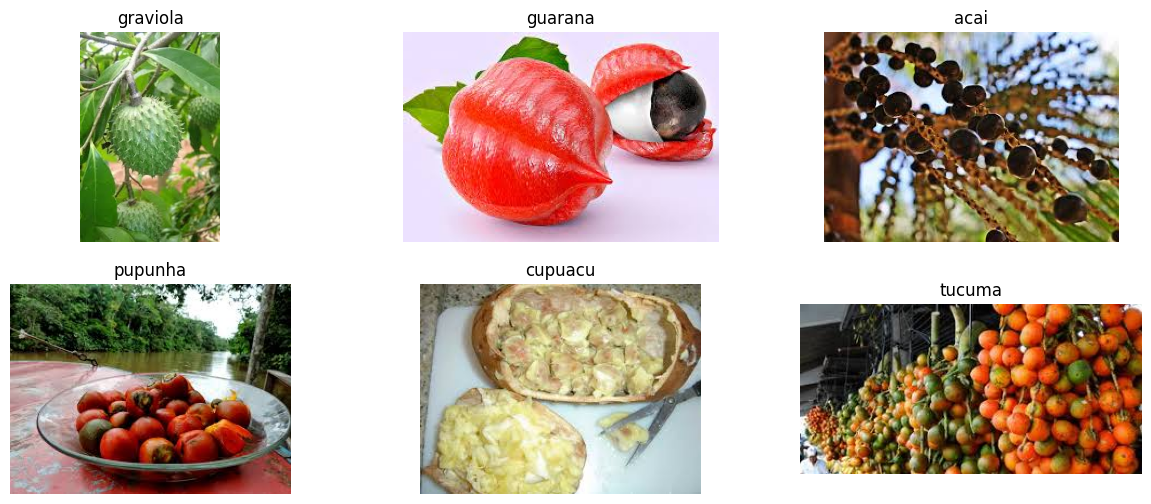

In [68]:
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report

classes = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
print("Classes:", classes)

plt.figure(figsize=(15,6))

for i, cls in enumerate(classes):
    cls_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(cls_path))
    img = Image.open(os.path.join(cls_path, img_name))

    plt.subplot(2, (len(classes)+1)//2, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.show()

**Check for Corrupted Image:**

 Write a script that verifies whether the image in the train directory are valid. If any corrupted images are found, the script must remove the image from the directory and print the message which image have been removed, if none found print ”No Corrupted Images Found.”

• Hint:

-Iterate through each class subdirectory and check if each image is valid.

-Use the Image.open() function to attempt to load each image.

-If the image is corrupted i.e. raises an IOError or SyntaxError, remove the image from the directory and print f"Removed corrupted image: {image_path}".

-Maintain a list of all corrupted image paths for reporting. • Expected Output: No corrupted images found

In [69]:
corrupted_images = []

for cls in classes:
    cls_path = os.path.join(train_dir, cls)
    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        try:
            img = Image.open(img_path)
            img.verify()
        except (IOError, SyntaxError):
            corrupted_images.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if len(corrupted_images) == 0:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


###Check Class Balance:

In [70]:

import os

class_counts = {}

for cls in classes:
    class_path = os.path.join(train_dir, cls)

    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path)
                  if img.lower().endswith(('.png', '.jpg', '.jpeg'))]

        class_counts[cls] = len(images)

print("\nClass Distribution:")
print("="*45)
print(f"{'Class Name':<25}{'Count':>15}")
print("="*45)

for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>15}")

print("="*45)


Class Distribution:
Class Name                         Count
graviola                              15
guarana                               15
acai                                  15
pupunha                               15
cupuacu                               15
tucuma                                15


###Data Generation & Preprocessing

####Create Train & Validation Dataset:

In [71]:
from tensorflow import keras
image_size = (224, 224)
batch_size = 32

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.


###Check Dataset Shape:

In [72]:


for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (32, 224, 224, 3)
Labels shape: (32,)


###Data Augmentation:

In [73]:

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
])

###Visualize Augmented Images:

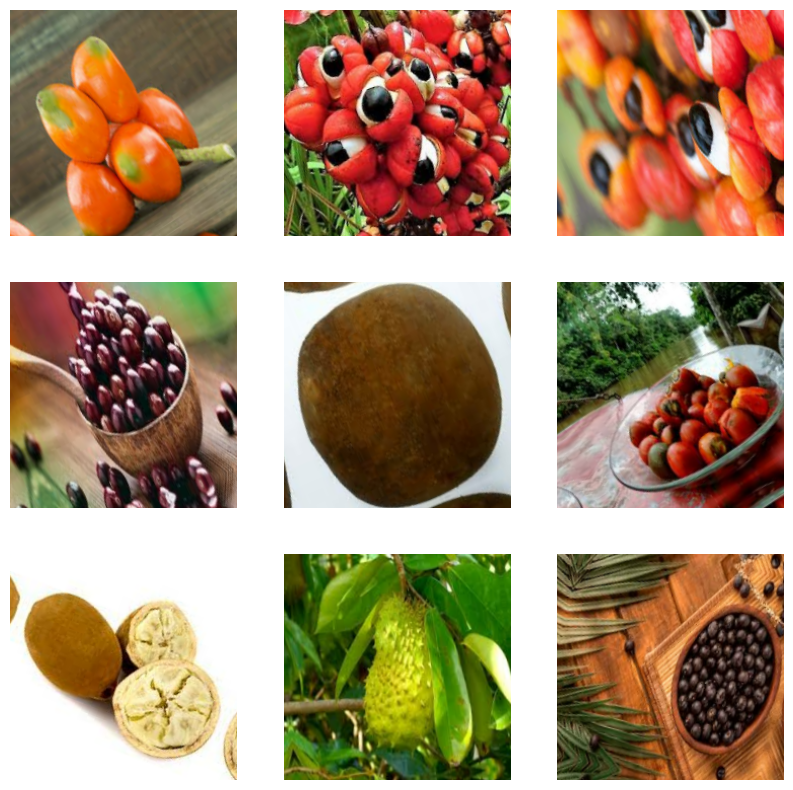

In [74]:

plt.figure(figsize=(10, 10))

for images, _ in train_ds.take(1):
    augmented_images = data_augmentation(images)

    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[i].numpy().astype("uint8"))
        plt.axis("off")

###Build a Deeper CNN Model (Batch Normalization and Dropout):

In [75]:

class_names = train_ds.class_names
model = keras.Sequential([

    layers.Input(shape=(224, 224, 3)),

    # Augmentation + Rescaling
     data_augmentation,
    layers.Rescaling(1./255),

    # Block 1
    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Block 4
    layers.Conv2D(256, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Dense Layers
    layers.Flatten(),

    layers.Dense(512),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    layers.Dense(64),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),


    # Output
    layers.Dense(len(class_names), activation='softmax')
])

###Compile Model

In [76]:

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

###Model Summary:

In [77]:

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_6 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_6 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_48          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_48 (Activation)      │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_48 (Dropout)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_49          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_49 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_49 (Dropout)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_50          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_50 (Activation)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_50 (Dropout)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_51          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_51 (Activation)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_51 (Dropout)            │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 50176)          │             

 Total params: 26,257,670 (100.17 MB)

 Trainable params: 26,254,790 (100.15 MB)

 Non-trainable params: 2,880 (11.25 KB)

###Define Callbacks:

In [78]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        "best_model.keras",
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    )
]

###Train Model:

In [79]:

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.2106 - loss: 2.0626
Epoch 1: val_loss improved from None to 1.82570, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 34s 9s/step - accuracy: 0.1944 - loss: 2.2211 - val_accuracy: 0.2222 - val_loss: 1.8257
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.1545 - loss: 2.2999
Epoch 2: val_loss did not improve from 1.82570
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 5s/step - accuracy: 0.1667 - loss: 2.2695 - val_accuracy: 0.0556 - val_loss: 1.8379
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.1453 - loss: 2.4389
Epoch 3: val_loss improved from 1.82570 to 1.80768, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 6s/step - accuracy: 0.1389 - loss: 2.4739 - val_accuracy: 0.1667 - val_loss: 1.8077
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.2546 - loss: 1.9488
Epoch 4: val_loss d

###Evaluate model:

In [80]:

loss, acc = model.evaluate(val_ds)
print(f"Validation Accuracy: {acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 891ms/step - accuracy: 0.1667 - loss: 1.8077
Validation Accuracy: 0.1667


#Task 2:
Implement transfer learning using a pre-trained model trained on ImageNet weights, freeze the layers of the model, and fit it only on the output layer to classify the fruits dataset.

Evaluate the model's performance and generate an inference output and classification report.

Did the performance improved compared to training from scratch.

Load Pretrained Model:

In [81]:
from tensorflow.keras.applications import VGG16
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
for layer in base_model.layers:
    layer.trainable = False

###Freeze Layers:

In [82]:
for layer in base_model.layers:
    layer.trainable = False

###Add Custom Layers

In [83]:
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(len(class_names), activation='softmax')(x)

###Final Model:

In [84]:
from tensorflow.keras.models import Model
model_tl = Model(inputs=base_model.input, outputs=outputs)

###Compile Model:

In [85]:
from tensorflow.keras.optimizers import Adam
model_tl.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


###Train Model

In [86]:

history_tl = model_tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    # callbacks=callbacks
)


Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 48s 15s/step - accuracy: 0.2222 - loss: 12.8975 - val_accuracy: 0.2778 - val_loss: 3.7831
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 87s 17s/step - accuracy: 0.2083 - loss: 7.4092 - val_accuracy: 0.3889 - val_loss: 5.0324
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 46s 15s/step - accuracy: 0.4444 - loss: 5.4287 - val_accuracy: 0.3889 - val_loss: 5.0576
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 47s 15s/step - accuracy: 0.4861 - loss: 4.3255 - val_accuracy: 0.4444 - val_loss: 4.1957
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 81s 15s/step - accuracy: 0.4583 - loss: 3.4363 - val_accuracy: 0.4444 - val_loss: 3.3887
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 83s 15s/step - accuracy: 0.6250 - loss: 2.1018 - val_accuracy: 0.5556 - val_loss: 2.9049
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 81s 15s/step - accuracy: 0.6528 - loss: 2.5229 - val_accuracy: 0.4444 - val_loss: 2.8584
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 47s 15s/step - accuracy: 0.7222 - loss: 1.2941 - val_accuracy: 0.5000 - val_loss: 2.8217

###Save Model:

In [87]:
model_tl.save("/content/vgg16_model.keras")

###Evaluate Model:

In [92]:

loss, acc = model_tl.evaluate(val_ds)
print(f"Transfer Learning Accuracy: {acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - accuracy: 0.5000 - loss: 2.8280
Transfer Learning Accuracy: 0.5000


###Predictions:

In [93]:

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model_tl.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

# Convert to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Sample Predictions:", y_pred[:10])
print("Actual Labels:     ", y_true[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
Sample Predictions: [4 2 1 5 2 5 1 3 0 4]
Actual Labels:      [4 4 1 5 1 0 1 5 3 0]


###Classification Report:

In [94]:

print("\nClassification Report:\n")

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))



Classification Report:

              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         3
     cupuacu       1.00      0.75      0.86         4
    graviola       0.25      1.00      0.40         1
     guarana       0.00      0.00      0.00         1
     pupunha       0.60      0.75      0.67         4
      tucuma       0.67      0.40      0.50         5

    accuracy                           0.50        18
   macro avg       0.42      0.48      0.40        18
weighted avg       0.55      0.50      0.50        18



In [95]:

print("MODEL PERFORMANCE COMPARISON")

cnn_loss, cnn_acc = model.evaluate(val_ds)
tl_loss, tl_acc = model_tl.evaluate(val_ds)

print(f"CNN from scratch accuracy: {cnn_acc:.4f}")
print(f"VGG16 Transfer Learning accuracy: {tl_acc:.4f}")

if tl_acc > cnn_acc:
    print("\n Transfer Learning performed better")
else:
    print("\n CNN performed better (unusual case due to dataset size)")

MODEL PERFORMANCE COMPARISON
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 684ms/step - accuracy: 0.1667 - loss: 1.8077
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - accuracy: 0.5000 - loss: 2.8280
CNN from scratch accuracy: 0.1667
VGG16 Transfer Learning accuracy: 0.5000

 Transfer Learning performed better
